# Assignment 3

In [6]:
import numpy as np
import sympy as sp
import scipy as sc
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

### 1. Introduction

In this document, we study a single pendulum by comparing theoretical predictions to real world data. 

The angle $\theta$ at which a pendulum hangs is governed by the following ODE:
$$
\ddot{\theta} + 2 \gamma \dot{\theta} + \omega^2 \sin(\theta) = 0
$$
where $\gamma \geq 0$ is a "damping coefficient" (how much friction slows the pendulum down) and $\omega > 0$ is the natural frequency of the pendulum. $\omega$ is related to the length of the pendulum $\ell$ and the acceleration incurred on it by gravity: $\omega = \sqrt{g/\ell}$.

The above equation has no closed-form expression, so we often consider it only when $\theta$ is small. In this case, we can apply the approximation $\sin(\theta) \approx \theta$ to simply the equation to $\ddot{\theta} + 2 \gamma \dot{\theta} + \omega^2 \theta = 0$. There is indeed a closed-form expression to this linearised model, as we are now working with a second-order ODE with constant coefficients. 

$$
\theta(t) = \theta_0c(t) + \left ( \frac{\eta_0 + \gamma \theta_0}{\omega_d} \right )s(t)
$$
Is that solution when we are considering the "underdamped" condition ($\gamma < \omega$) and initial conditions $\theta(0) = \theta_0$ and $\dot{\theta}(0) = \eta_0$. The functions $c(t)$, $s(t)$ and constant $\omega_d$ are defined as follows:

$$
\begin{align}
c(t) &= e^{-\gamma t}\cos{(\omega_d t)} \\
s(t) &= e^{- \gamma t}\sin{(\omega_d t)} \\
\omega_d &= \sqrt{\omega^2 - \gamma^2}
\end{align}
$$

$\omega_d$ is the *damped natural frequency*.

### 2. Verifying the exact solution

#### 2.1: Checking the mathematics

To verify that the claims in the introduction are true, see the below python code.

First, we set up our symbolic variables and define $c$, $s$ and $\theta$ in terms of them. We then use `sympy` to find the first and second derivatives of $\theta$ with respect to time. Finally we construct the ODE using $\theta$ and it's derivatives. 

We then run the following checks:
1. At time $t = 0$ we expect our solution to take the value $\theta_0$. To do this we use `.subs` to substitute the value $0$ for $t$, and then `.simplify` to symbolically check we have $\theta_0$. 
2. Similarly we expect $\dot{\theta}$ to produce $\eta_0$ when we sub $t=0$. 
3. We check that $\theta$ and it's derivatives subbed into the ODE simplifies to $0$, in other words, satisfy the differential equation.

In [ ]:
# Setup some symbols
ts, gamma, omega_d = sp.symbols('t gamma omega_d', real=True)

# Initial condition symbols
theta_0, eta_0 = sp.symbols('theta_0 eta_0', real=True)

# Define c(t) and s(t)
c = sp.exp(-gamma*ts) * sp.cos(omega_d*ts)
s = sp.exp(-gamma*ts) * sp.sin(omega_d*ts)

# Define theta(t), this is the solution to the ODE
theta = theta_0 * c + ((eta_0 + gamma*theta_0)/omega_d) * s

# Derivatives
theta_dot = sp.diff(theta, ts)
theta_ddot = sp.diff(theta_dot, ts)

# ODE: theta'' + 2\gamma theta' + (\omega_d^2 + \gamma^2) theta
ode_expr = theta_ddot + 2*gamma*theta_dot + (omega_d**2 + gamma**2)*theta


# ---- Checks ----
# \theta_0 should be what we get at t=0
print("Check 1: theta(0) = theta_0")
print(sp.simplify(theta.subs(ts, 0)))

# We expect \eta_0 as the initial angular velocity
print("\nCheck 2: theta'(0) = eta_0")
print(sp.simplify(theta_dot.subs(ts, 0)))

# ODE with theta and it's derivatives should simplify to 0,
# which means theta solves the ODE.
print("\nCheck 3: ODE satisfied (should be 0)")
print(sp.simplify(ode_expr))

Check 1: theta(0) = theta_0
theta_0

Check 2: theta'(0) = eta_0
eta_0

Check 3: ODE satisfied (should be 0)
0


#### 2.2: Plotting the solution

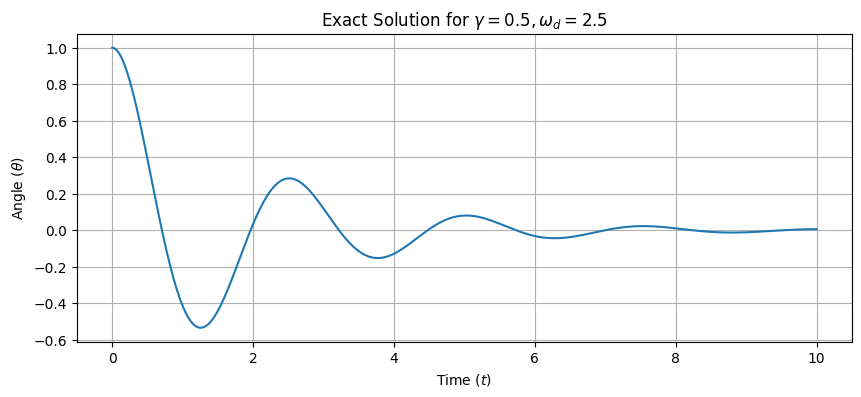

In [27]:
def cos_exp(ts, gamma, omega_d):
    return np.exp(-gamma*ts) * np.cos(omega_d*ts)

def sin_exp(ts, gamma, omega_d):
    return np.exp(-gamma*ts) * np.sin(omega_d*ts)


def plot_exact(gamma, omega_d, theta0, eta0, t_max=10, num_points=1000):
    """
    Plot the exact solution for given parameters.

    :param gamma: Damping coefficient
    :param omega_d: Damped frequency
    :param theta0: Initial angle
    :param eta0: Initial angular velocity
    :param t_max: Maximum time to plot
    :param num_points: Number of points in the plot
    """
    ts = np.linspace(0, t_max, num_points)
    cs = cos_exp(ts, gamma, omega_d)
    ss = sin_exp(ts, gamma, omega_d)
    thetas = theta0 * cs + ((eta0 + gamma*theta0)/omega_d) * ss
    
    plt.figure(figsize=(10, 4))
    plt.plot(ts, thetas)
    plt.title(f'Exact Solution for $\\gamma={gamma}, \\omega_d={omega_d}$')
    plt.xlabel('Time ($t$)')
    plt.ylabel('Angle ($\\theta$)')
    plt.grid()
    plt.show()


plot_exact(gamma=0.5, omega_d=2.5, theta0=1, eta0=0)

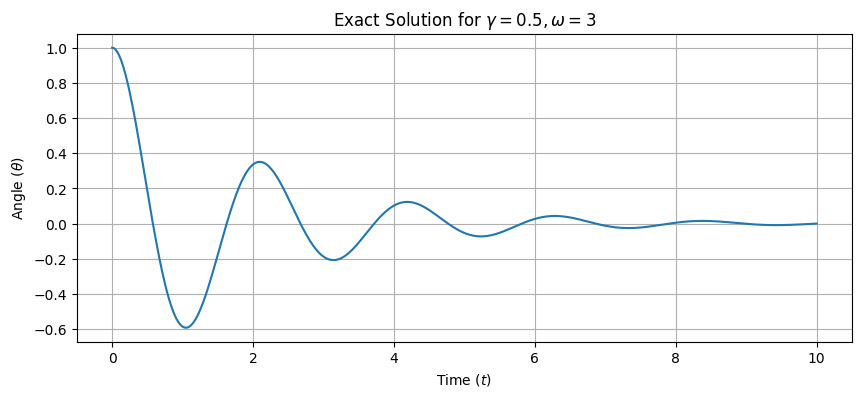

Above is the plot of $\theta$ against time with parameters $\gamma=0.5$, $\omega=3$, $\theta_0 = 1$ and $\eta_0 = 0$. It shows a clear damped oscillating pattern. "oscillating" here describes the solution moving up and down in a regular fashion, like a wave, and the "damped" part describes the magnitude of this wave gradually decreasing. 




### Part 3: Fitting a linear model

#### 3.1: Plotting the data

Head of 'pendulum1.csv':
   Unnamed: 0     t     theta
0           0  3.00  0.445173
1           1  3.04  0.275452
2           2  3.08  0.206092
3           3  3.12  0.284490
4           4  3.16  0.382913

Column names:
Unnamed: 0, t, theta

Data types:
Unnamed: 0      int64
t             float64
theta         float64
dtype: object


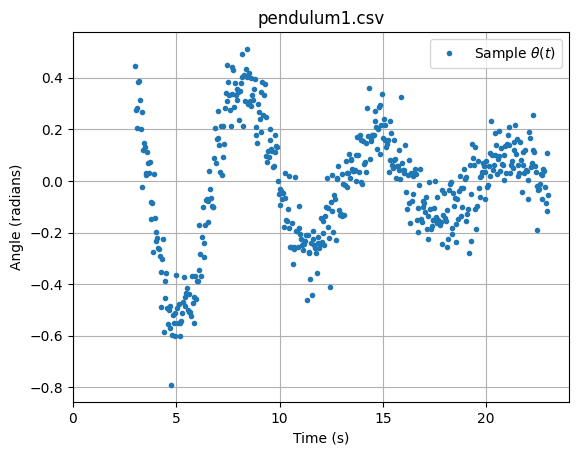

In [33]:
# Read the CSV file into a DataFrame
df = pd.read_csv("pendulum1.csv")

# Inspect the head of the dataframe
print("Head of 'pendulum1.csv':")
print(df.head())

# Print column names and data types
print("\nColumn names:")
print(*list(df.columns), sep=", ")
print("\nData types:")
print(df.dtypes)

# ---- Plotting ----
plt.figure()

# Create plot from columns 1 (time) and 2 (angle) of the dataframe
plt.plot(df.iloc[:, 1], df.iloc[:, 2], ".", label="Sample $\\theta(t)$")

# Force x-axis to start at 0
plt.xlim(left=0)

# Add labels and legend
plt.xlabel("Time (s)")
plt.ylabel("Angle (radians)")
plt.title("pendulum1.csv")
plt.legend()
plt.grid()

plt.show()

Plot of data from `pendulum1.csv` file. We see there is an oscillatory relationship between $\theta$ (angle of the pendulum in radians) and time $t$.  

#### 3.2: Fitting a model

We will now fit a model to this data by using a two parameter linear model described as such
$$
F(t; \beta_0, \beta_1) \equiv \beta_0 \phi_0(t) + \beta_1 \phi_1(t)
$$

where $\beta_0$ and $\beta_1$ are parameters, $\phi_0(t) = c(t)$ and $\phi_1(t) = s(t)$ are the functions from part 1.




By inspecting the $\theta(t)$ expression we can determine the values of $\theta_0$ and $\eta_0$ based off $\beta_0$ and $\beta_1$. 

$$
\theta(t) = \theta_0c(t) + \left ( \frac{\eta_0 + \gamma \theta_0}{\omega_d} \right )s(t)
$$

Note that $\theta_0$ is the coefficient of cosine in this expression, and that $\beta_0$ is the coefficient of cosine in our linear model, so we deduce that $\theta_0 = \beta_0$. Similarly, the coefficient of sine in the expression delivers us our expression for $\eta_0$.

$$

\beta_1 = \frac{\eta_0 + \gamma \theta_0}{\omega_d}
\implies \eta_0 = \beta_1 \omega_d - \gamma \theta_0

$$

beta0 = -0.40662775771420345, beta1 = 0.7767633670216031
Estimated theta0 = -0.406628
Estimated eta0   = 0.813533


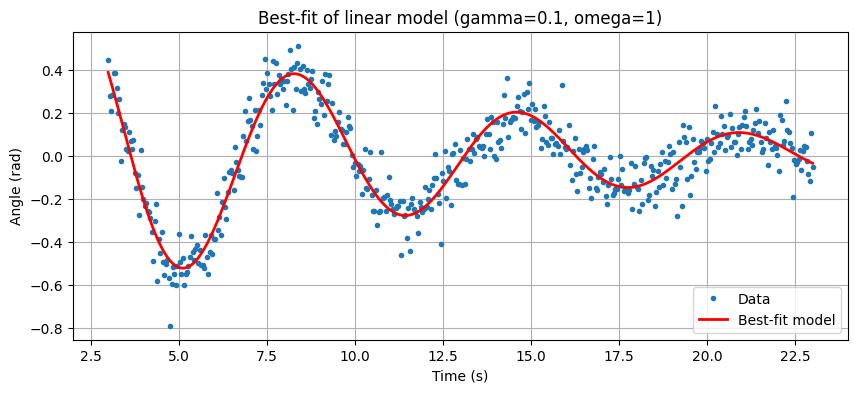

In [37]:
# This data is generated from a pendulum with known natural frequency 1
# and damping coefficient 0.1.
gamma = 0.1
omega = 1
omega_d = np.sqrt(omega**2 - gamma**2)


# Extract data from the dataframe
df = pd.read_csv("pendulum1.csv")
ts = df.iloc[:, 1].values      # t
thetas = df.iloc[:, 2].values  # theta


# 1. Build X (size N x 2) with phi_0 = c(t) and phi_1 = s(t)
X = np.column_stack([cos_exp(ts, gamma, omega_d), sin_exp(ts, gamma, omega_d)])

# 2. Build A = X^T X and b = X^T theta
A = X.T @ X
b = X.T @ thetas


# 3. Solve for beta = [beta0, beta1]
beta = np.linalg.solve(A, b)
beta0, beta1 = beta
print(f"beta0 = {beta0}, beta1 = {beta1}")


# 4. Recover theta0 and eta0
theta0_hat = beta0
eta0_hat = beta1 * omega_d - gamma * theta0_hat
print(f"Estimated theta0 = {theta0_hat:.6g}")
print(f"Estimated eta0   = {eta0_hat:.6g}")


# ------ Plot  ------
prediction_data = X @ beta

plt.figure(figsize=(10,4))
plt.plot(ts, thetas, '.', label='Data')
plt.plot(ts, prediction_data, '-', label='Best-fit model', linewidth=2, color='red')
plt.xlabel('Time (s)')
plt.ylabel('Angle (rad)')
plt.title(f'Best-fit of linear model (gamma={gamma}, omega={omega})')
plt.legend(loc='lower right')
plt.grid(True)

plt.show()

As the natural frequency $\omega$ and damping coefficient $\gamma$ are known for this pendulum, which allows us to create a well-fitting model.

### 4. Parameter estimation by curve fitting

#### Task 4.1: Cleaning the data

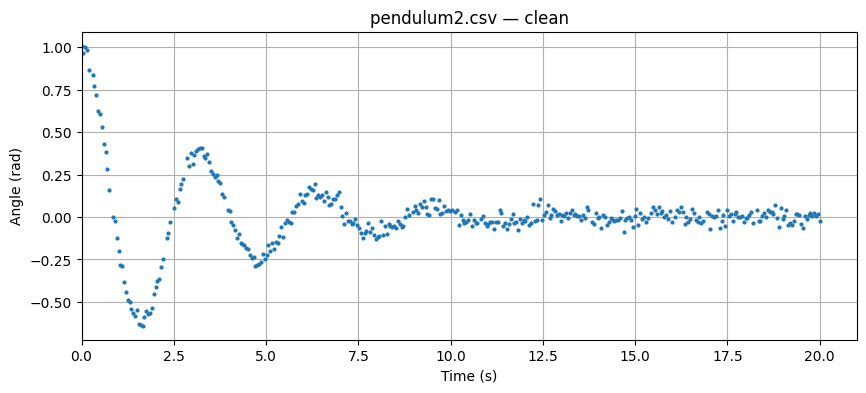

In [46]:
# Load data
df2 = pd.read_csv("pendulum2.csv")
t_col = df2.iloc[:, 0]
theta_col = df2.iloc[:, 1]

# (a) Remove rows with missing values
df2 = df2.dropna()


# (b) Remove implausible values of theta
mask = np.abs(theta_col) <= (np.pi / 2)
df2_clean = df2.loc[mask]


# (c) Convert cleaned data to numpy array
ts2 = df2_clean.iloc[:, 0].values
thetas2 = df2_clean.iloc[:, 1].values


# ------ Plot  ------
plt.figure(figsize=(10,4))
plt.plot(ts2, thetas2, '.', markersize=4)
plt.xlabel("Time (s)")
plt.ylabel("Angle (rad)")
plt.title("pendulum2.csv — clean")
plt.grid(True)
plt.xlim(left=0)
plt.show()

The cleaned data from `pendulum2.csv` is consistent with a underdamped pendulum. We can clearly see an oscillatory motion which has a gradually decreasing amplitude. 

#### Task 4.2: Estimating parameters

Estimated parameters:
 gamma = 0.294853
 omega_d = 1.98124
 theta0 = 0.988428
 eta0 = 0.0217437


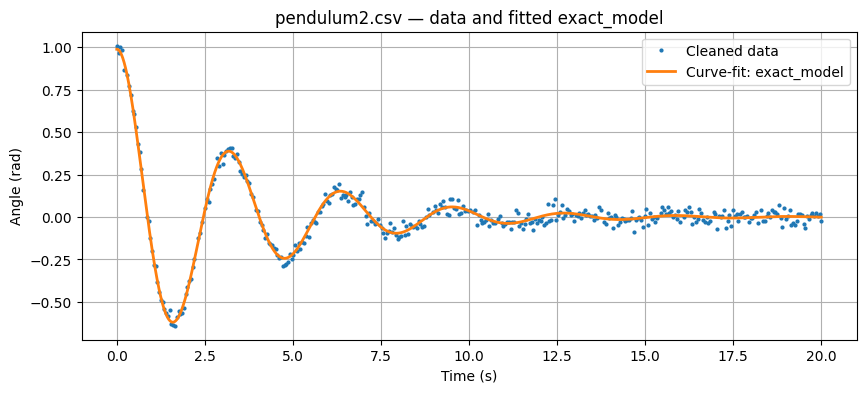

In [ ]:

def exact_model(t, gamma, omega_d,  theta0, eta0):
    """Right-hand side of equation (C): theta(t) for parameters gamma, omega_d, theta0, eta0."""
    t = np.asarray(t)
    c = np.exp(-gamma * t) * np.cos(omega_d * t)
    s = np.exp(-gamma * t) * np.sin(omega_d * t)
    return theta0 * c + ((eta0 + gamma * theta0) / omega_d) * s


# ------ Initial guess for parameters ------
gamma0 = 0.05                   # A small positive quantity
theta0_0 = thetas2[0]           # Approximately the first angle measurement
eta0_0 = 0.0                    # Around 0

# To estimate omega_d, we need the approximate period of oscillation, T.
# To find this, we can use the "find_peaks" function from scipy to identify
# The peaks of each wave, from which we calculate T.
peaks_mask = sc.signal.find_peaks(thetas2)[0]
peak_times = ts2[peaks_mask]
periods = np.diff(peak_times)  # The difference between each time
T_est = np.median(periods)     # Take an average of these differences for T

omega_d0 = 2 * np.pi / T_est

# --------- Compute parameter estimates using curve_fit ---------
p0 = [gamma0, omega_d0, theta0_0, eta0_0]
params_est, param_cov = sc.optimize.curve_fit(exact_model, ts2, thetas2, p0=p0,  maxfev=10000)

gamma_hat, omega_d_hat, theta0_hat, eta0_hat = params_est

print("Estimated parameters:")
print(f" gamma = {gamma_hat:.6}")
print(f" omega_d = {omega_d_hat:.6}")
print(f" theta0 = {theta0_hat:.6}")
print(f" eta0 = {eta0_hat:.6}")


# ------ Plot  ------
t_fit = np.linspace(ts2.min(), ts2.max(), 2000)
y_fit = exact_model(t_fit, gamma_hat, omega_d_hat, theta0_hat, eta0_hat)

plt.figure(figsize=(10,4))
plt.plot(ts2, thetas2, '.', markersize=4, label='Cleaned data')
plt.plot(t_fit, y_fit, '-', linewidth=2, label='Curve-fit: exact_model')
plt.xlabel('Time (s)')
plt.ylabel('Angle (rad)')
plt.title('pendulum2.csv — data and fitted exact_model')
plt.legend()
plt.grid(True)
plt.show()